<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/aula13_decisao_metricas_aluno_ProEducador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 13 – Escolha de métrica, custo dos erros e interpretação para decisão

## Versão do aluno

### Objetivo da aula
Interpretar os resultados dos modelos e propor uma decisão técnica preliminar com base nas métricas e no custo dos erros.

### Instruções
Complete as células indicadas e registre suas interpretações ao longo da atividade.  
Nesta aula, o foco principal é transformar os resultados em **decisão técnica justificada**.


## 1. Importação das bibliotecas

Importe as bibliotecas necessárias para:
- leitura e manipulação da base;
- visualização;
- pré-processamento;
- treino dos classificadores;
- cálculo das métricas.


In [28]:
# Complete aqui
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve
)

In [29]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Leitura da base

Leia o arquivo `dados_aula13_decisao_metricas.csv` e exiba as primeiras linhas.


In [30]:
# Complete aqui
df = pd.read_csv('/content/drive/MyDrive/Classroom/Deep Learning Pró Educador/dados_aula13_decisao_metricas.csv')
df.head()

,id_registro,linha,turno,produto,temperatura_c,pressao_bar,vibracao_mm_s,abertura_valvula_pct,consumo_energia_kwh,tempo_resposta_s,erro_vazao_pct,leituras_invalidas,horas_operacao_bomba,falha_critica
0,DEC_0001,Linha_A,Manhã,Solvente,50.58,4.02,1.41,82.25,23.21,2.97,3.61,3,280.5,0
1,DEC_0002,Linha_A,Tarde,Acido,42.94,3.93,2.53,55.45,25.69,2.59,2.30,0,334.8,0
2,DEC_0003,Linha_C,Tarde,Acido,49.45,3.85,2.14,73.50,14.31,2.83,5.60,2,451.1,1
3,DEC_0004,Linha_B,Tarde,Base,NaN,3.32,1.46,59.60,18.74,2.19,2.72,1,242.2,0
4,DEC_0005,Linha_B,Manhã,Acido,37.61,3.00,0.44,52.77,22.93,1.95,3.15,1,374.9,0


## 3. Inspeção inicial da base

Verifique:
- dimensão da base;
- tipos de dados;
- valores faltantes;
- duplicatas;
- distribuição da variável-alvo.


In [31]:
# Complete aqui
print('Dimensão da base:', df.shape)
print('\nTipos de dados:')
print(df.dtypes)
print('\nValores faltantes:')
print(df.isna().sum())
print('\nDuplicatas:', df.duplicated().sum())
print('\nDistribuição da variável-alvo:')
print(df['falha_critica'].value_counts)

Dimensão da base: (392, 14)

Tipos de dados:
id_registro              object
linha                    object
turno                    object
produto                  object
temperatura_c           float64
pressao_bar             float64
vibracao_mm_s           float64
abertura_valvula_pct    float64
consumo_energia_kwh     float64
tempo_resposta_s        float64
erro_vazao_pct          float64
leituras_invalidas        int64
horas_operacao_bomba    float64
falha_critica             int64
dtype: object

Valores faltantes:
id_registro             0
linha                   0
turno                   0
produto                 8
temperatura_c           8
pressao_bar             8
vibracao_mm_s           0
abertura_valvula_pct    0
consumo_energia_kwh     0
tempo_resposta_s        8
erro_vazao_pct          0
leituras_invalidas      0
horas_operacao_bomba    0
falha_critica           0
dtype: int64

Duplicatas: 12

Distribuição da variável-alvo:
<bound method IndexOpsMixin.value_counts of 0   

**Registro do aluno:**  
-  
-  
-  


## 4. Visualização do desbalanceamento

Calcule a distribuição da variável-alvo e crie um gráfico de barras.


In [32]:
# Complete aqui
dist = df['falha_critica'].value_counts().sort_index()
dist.index = ['Sem falha crítica (0)', 'Falha crítica (1)']
dist

,count
Sem falha crítica (0),329
Falha crítica (1),63


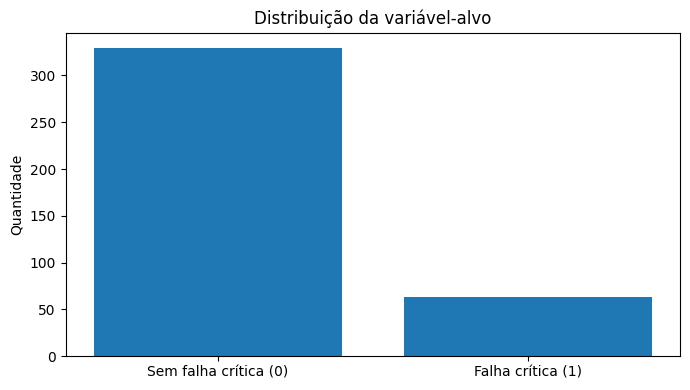

In [33]:
# Gere o gráfico aqui
plt.figure(figsize=(7,4))
plt.bar(dist.index, dist.values)
plt.title('Distribuição da variável-alvo')
plt.ylabel('Quantidade')
plt.tight_layout()
plt.show()

## 5. Limpeza básica

Remova as duplicatas da base.


In [34]:
# Complete aqui
df = df.drop_duplicates().copy()
print(df.shape)

(380, 14)


## 6. Definição de X e y

Separe:
- `X`: variáveis de entrada;
- `y`: variável-alvo binária `falha_critica`.

**Pergunta:**  
Por que `id_registro` não deve ser usado como preditora?


In [35]:
# Complete aqui
X = df.drop(columns=['id_registro', 'falha_critica'])
y = df['falha_critica']

print(X.shape)
print(y.shape)

(380, 12)
(380,)


**Resposta do aluno:**  


## 7. Divisão em treino e teste

Faça a divisão usando `stratify=y`.


In [36]:
# Complete aqui
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print('Treino:', X_train.shape, y_train.shape)
print('Teste:', X_test.shape, y_test.shape)
print('\nDistribuição em y_train:')
print(y_train.value_counts())
print('\nDistribuição em y_test:')
print(y_test.value_counts())

Treino: (285, 12) (285,)
Teste: (95, 12) (95,)

Distribuição em y_train:
falha_critica
0    239
1     46
Name: count, dtype: int64

Distribuição em y_test:
falha_critica
0    80
1    15
Name: count, dtype: int64


## 8. Pré-processamento com pipeline

Monte um pipeline com:
- imputação da mediana + padronização para numéricas;
- imputação da moda + one-hot encoding para categóricas.


In [43]:
from numpy.random.mtrand import standard_exponential
# Complete aqui
colunas_numericas = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
colunas_categoricas = X.select_dtypes(include=['object']).columns.tolist()

transformador_numerico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler)
])

transformador_categorico = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy=('most_frequent'))),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessador = ColumnTransformer(transformers=[
    ('num', transformador_numerico, colunas_numericas),
    ('cat', transformador_categorico, colunas_categoricas)
])

## 9. Criação dos classificadores

Crie:
- um modelo de Regressão Logística;
- um modelo de Árvore de Decisão Classificadora.


In [44]:
# Complete aqui
modelo_logistico = Pipeline(steps=[
    ('preprocessador', preprocessador),
    ('modelo', LogisticRegression(max_iter=1000))
])

modelo_arvore = Pipeline(steps=[
    ('preprocessador', preprocessador),
    ('modelo', DecisionTreeClassifier(max_depth=5, random_state=42))
])

## 10. Treino dos modelos

Treine os dois classificadores.


In [45]:
# Complete aqui
modelo_logistico.fit(X_train, y_train)
modelo_arvore.fit(X_train, y_train)

print('Modelos treinados com sucesso.')

Modelos treinados com sucesso.


## 11. Predições e probabilidades

Gere:
- classes previstas;
- probabilidades da classe positiva.


In [46]:
# Complete aqui
pred_log = modelo_logistico.predict(X_test)
pred_tree = modelo_arvore.predict(X_test)

proba_log = modelo_logistico.predict_proba(X_test)[:, 1]
proba_tree = modelo_arvore.predict_proba(X_test)[:, 1]

## 12. Matrizes de confusão

Calcule as matrizes de confusão e faça a visualização.


In [47]:
# Complete aqui
cm_log = confusion_matrix(y_test, pred_log)
cm_tree = confusion_matrix(y_test, pred_tree)

print(cm_log)
print(cm_tree)

[[79  1]
 [ 7  8]]
[[72  8]
 [15  0]]


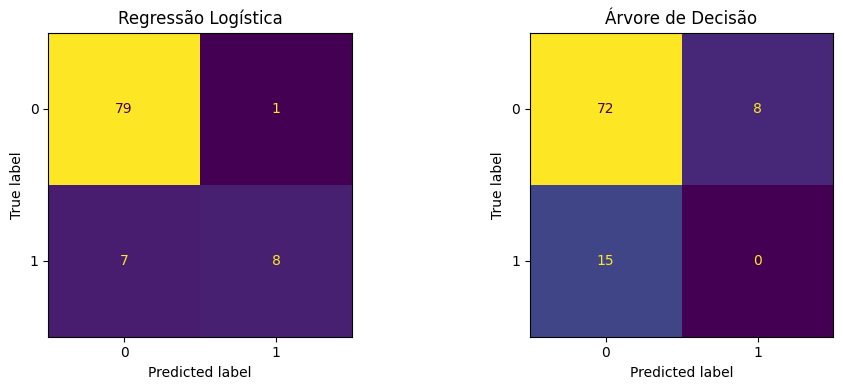

In [48]:
# Gere a visualização aqui
fig, axes = plt.subplots(1, 2, figsize=(10,4))

ConfusionMatrixDisplay(cm_log).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Regressão Logística')

ConfusionMatrixDisplay(cm_tree).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Árvore de Decisão')

plt.tight_layout()
plt.show()

## 13. Cálculo das métricas

Calcule:
- acurácia;
- precisão;
- recall;
- F1-score;
- AUC.


In [54]:
# Complete aqui
metricas = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Árvore de Decisão'],
    'Acurácia': [
        accuracy_score(y_test, pred_log),
        accuracy_score(y_test, pred_tree)
    ],
    'Precisão': [
        precision_score(y_test, pred_log, zero_division=0),
        precision_score(y_test, pred_tree, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, pred_log, zero_division=0),
        recall_score(y_test, pred_tree, zero_division=0)
    ],
    'F1-score': [
        f1_score(y_test, pred_log, zero_division=0),
        f1_score(y_test, pred_log, zero_division=0)
    ],
    'AUC': [
        roc_auc_score(y_test, proba_log),
        roc_auc_score(y_test, proba_tree)
    ]
}).round(4)

metricas

,Modelo,Acurácia,Precisão,Recall,F1-score,AUC
0,Regressão Logística,0.9158,0.8889,0.5333,0.6667,0.9092
1,Árvore de Decisão,0.7579,0.0000,0.0000,0.6667,0.5254


## 14. Visualização comparativa das métricas

Crie gráficos comparando os dois modelos.


In [55]:
# Complete aqui
metricas_plot = metricas.set_index('Modelo')

In [ ]:
# Gere os gráficos aqui para Acurácia, Precisão, Recall, F1-score e AUC

## 15. Curva ROC e AUC

Calcule a curva ROC e monte o gráfico comparativo.


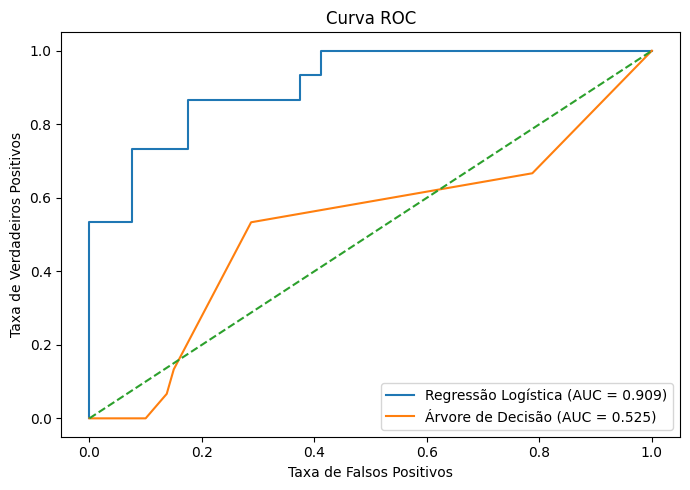

In [56]:
# Complete aqui
fpr_log, tpr_log, _ = roc_curve(y_test, proba_log)
fpr_tree, tpr_tree, _ = roc_curve(y_test, proba_tree)

plt.figure(figsize=(7,5))
plt.plot(fpr_log, tpr_log, label=f'Regressão Logística (AUC = {roc_auc_score(y_test, proba_log):.3f})')
plt.plot(fpr_tree, tpr_tree, label=f'Árvore de Decisão (AUC = {roc_auc_score(y_test, proba_tree):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.tight_layout()
plt.show()

## 16. Estudo de custo dos erros

Considere o cenário:
- **Falso positivo (FP)**: custo de R$ 1.500

- **Falso negativo (FN)**: custo de R$ 12.000

Calcule o custo estimado dos erros para cada modelo.


In [58]:
# Complete aqui
def custo_erros(cm, custo_fp=1500, custo_fn=12000):
    tn, fp, fn, tp = cm.ravel()
    custo_total = fp * custo_fp + fn * custo_fn
    return fp, fn, custo_total

fp_log, fn_log, custo_log = custo_erros(cm_log)
fp_tree, fn_tree, custo_tree = custo_erros(cm_tree)

custos = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'Árvore de Decisão'],
    'Falsos Positivos': [fp_log, fp_tree],
    'Falsos Negativos': [fn_log, fn_tree],
    'Custo estimado (R$)': [custo_log, custo_tree]
})

custos

,Modelo,Falsos Positivos,Falsos Negativos,Custo estimado (R$)
0,Regressão Logística,1,7,85500
1,Árvore de Decisão,8,15,192000


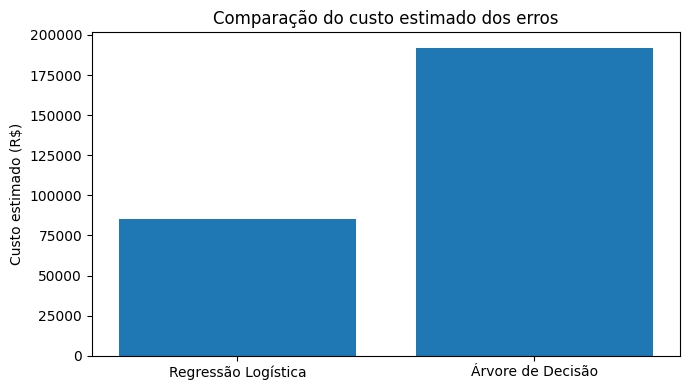

In [60]:
# Gere o gráfico aqui
plt.figure(figsize=(7,4))
plt.bar(custos['Modelo'], custos['Custo estimado (R$)'])
plt.title('Comparação do custo estimado dos erros')
plt.ylabel('Custo estimado (R$)')
plt.tight_layout()
plt.show()

## 17. Escolha da métrica adequada

Responda:
- qual métrica parece mais importante neste caso;
- por quê;
- qual erro traz maior risco operacional.


**Resposta do aluno:**  
- **Métrica mais importante:** Recall (Sensibilidade) ou AUC.  

- **Justificativa:** A 'falha_critica' (falha crítica) tem um alto custo associado (R$ 12.000 por Falso Negativo), e o Recall mede a capacidade do modelo de identificar corretamente essas falhas críticas. Minimizar Falsos Negativos é crucial para evitar custos elevados e impactos operacionais graves. O AUC também é relevante por considerar o balanço entre Falsos Positivos e Falsos Negativos em diferentes limiares, mas o Recall foca diretamente na identificação das falhas reais.  

- **Erro mais crítico:** Falsos Negativos. Este erro representa o custo mais alto (R$ 12.000) e significa que uma falha crítica real não foi detectada pelo sistema, podendo levar a consequências operacionais severas e perdas financeiras significativas.

## 18. Quadro de decisão com justificativas

Preencha um quadro de decisão resumindo:
- desempenho geral;
- capacidade de detectar falhas críticas;
- controle de alarmes indevidos;
- custo estimado dos erros;
- recomendação preliminar.


In [61]:
# Complete aqui
quadro_decisao = pd.DataFrame({
    'Critério': [
        'Desempenho geral',
        'Capacidade de detectar falhas críticas',
        'Controle de alarmes indevidos',
        'Custo estimado dos erros',
        'Recomendação preliminar'
    ],
    'Análise do aluno': [
        'Desempenho Geral',
        'Capacidade de detectar falhas críticas',
        'Controle de alarmes indevidos',
        'Custo estimado dos erros',
        'Adequação ao contexto industrial',

    ]
})

quadro_decisao

,Critério,Análise do aluno
0,Desempenho geral,Desempenho Geral
1,Capacidade de detectar falhas críticas,Capacidade de detectar falhas críticas
2,Controle de alarmes indevidos,Controle de alarmes indevidos
3,Custo estimado dos erros,Custo estimado dos erros
4,Recomendação preliminar,Adequação ao contexto industrial


## 19. Parecer técnico preliminar

Escreva um parecer técnico curto indicando:
- qual modelo parece mais adequado;
- qual métrica foi priorizada;
- qual o principal argumento para a decisão.


**Parecer técnico preliminar:**
Com base na análise detalhada de desempenho e custos, o modelo de **Regressão Logística** é considerado o mais adequado para o problema de detecção de falhas críticas. A métrica priorizada nesta decisão foi o **Recall (Sensibilidade)**, juntamente com a minimização de **Falsos Negativos**.

O principal argumento para esta decisão é a capacidade superior da Regressão Logística em identificar falhas críticas reais, conforme evidenciado por um Recall significativamente maior (0.5333) em comparação com a Árvore de Decisão (0.0000). Dado o elevadíssimo custo associado a cada Falso Negativo (R$ 12.000), a melhor performance da Regressão Logística na detecção destas falhas resulta em um

**custo estimado total de erros substancialmente menor** (R$ 85.500 vs. R$ 192.000 da Árvore de Decisão). Assim, a Regressão Logística oferece uma solução mais segura e economicamente vantajosa para mitigar os riscos operacionais.

## 20. Exportação dos resultados

Salve:
- a tabela de métricas;
- a tabela de custos;
- o quadro de decisão.


In [62]:
# Complete aqui
metricas.to_csv('metricas_decisao_aula13.csv', index=False)
custos.to_csv('custos_erros_aula13.csv', index=False)
quadro_decisao.to_csv('quadro_decisao_aula13.csv', index=False)
print('Arquivos exportados com sucesso.')

Arquivos exportados com sucesso.


## 21. Fechamento

Verifique se você:
- relacionou métricas ao custo dos erros;
- interpretou os resultados com coerência técnica;
- comparou modelos considerando impacto operacional;
- estruturou o raciocínio decisório de forma objetiva.
